<a href="https://colab.research.google.com/github/ariffu/AWS-BMKG/blob/master/colab_asrs_sta6010_lstm_end_to_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASRS STA6010 LSTM end to end

Notebook ini adalah versi `.ipynb` dari file `colab_asrs_sta6010_lstm_end_to_end.py` yang sudah dirapikan supaya bisa langsung dibuka di Google Colab.

Versi ini juga diarahkan ke **latest preprocessing output** terlebih dulu, dengan urutan prioritas file:

1. `asrs_sta6010_overlap_aware_preprocessing_v2_2023_2025.csv`
2. `asrs_sta6010_basic_enriched_with_aws_v1.csv`
3. `asrs_sta6010_basic_preprocessing_v1.csv`
4. `asrs_sta6010_fe_v2_lstm_train_ready_full.csv`


In [ ]:
# This cell installs and imports the basic dependencies for Colab runtime
%pip -q install nbformat tqdm seaborn scikit-learn joblib tensorflow


Using existing data file: asrs_sta6010_fe_v2_lstm_train_ready_full.csv


/tmp/ipykernel_6466/650136585.py:64: DtypeWarning: Columns (15,19,20,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, on_bad_lines='skip')


                      ts_utc            timestamp                   local_dt  \
0  2023-01-01 01:00:00+00:00  2023-01-01 01:00:00  2023-01-01 01:00:00+00:00   
1  2023-01-01 01:10:00+00:00  2023-01-01 01:10:00  2023-01-01 01:10:00+00:00   
2  2023-01-01 01:20:00+00:00  2023-01-01 01:20:00  2023-01-01 01:20:00+00:00   
3  2023-01-01 01:30:00+00:00  2023-01-01 01:30:00  2023-01-01 01:30:00+00:00   
4  2023-01-01 01:40:00+00:00  2023-01-01 01:40:00  2023-01-01 01:40:00+00:00   

   local_date id_stasiun nama_stasiun  ghi_basic  dhi_basic  dni_basic  \
0  2023-01-01    STA6010   ASRS Mlati      266.8      257.3       18.9   
1  2023-01-01    STA6010   ASRS Mlati      508.5      360.2      234.5   
2  2023-01-01    STA6010   ASRS Mlati      551.0      412.1      204.3   
3  2023-01-01    STA6010   ASRS Mlati      403.3      401.7        3.1   
4  2023-01-01    STA6010   ASRS Mlati      449.0      443.3        6.6   

   hour_wib  ...  cloudiness_proxy  radiation_complete_case_flag_v4  \
0  

/tmp/ipykernel_6466/650136585.py:115: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_raw[col].fillna(mean_val, inplace=True)
/tmp/ipykernel_6466/650136585.py:116: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

(170226, 18, 43)
(170226, 6)
(36459, 18, 43)
(36459, 6)
(36459, 18, 43)
(36459, 6)


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 18, 64)         │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,318 (161.40 KB)

 Trainable params: 41,318 (161.40 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - loss: 0.1634 - mae: 0.2212 - val_loss: 0.1119 - val_mae: 0.1779 - learning_rate: 0.0010
Epoch 2/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 69s 26ms/step - loss: 0.1397 - mae: 0.1904 - val_loss: 0.1140 - val_mae: 0.2018 - learning_rate: 0.0010
Epoch 3/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 83s 26ms/step - loss: 0.1352 - mae: 0.1834 - val_loss: 0.1187 - val_mae: 0.2243 - learning_rate: 0.0010
Epoch 4/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - loss: 0.1314 - mae: 0.1793 - val_loss: 0.1265 - val_mae: 0.2388 - learning_rate: 0.0010
Epoch 5/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 75s 28ms/step - loss: 0.1260 - mae: 0.1724 - val_loss: 0.1245 - val_mae: 0.2389 - learning_rate: 5.0000e-04
Epoch 6/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - loss: 0.1235 - mae: 0.1701 - val_loss: 0.1256 - val_mae: 0.2402 - learning_rate: 5.0000e-04
Epoch 7/30
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - loss: 0.1214 - mae: 0.1681 - val_loss: 0.1265 - val_m

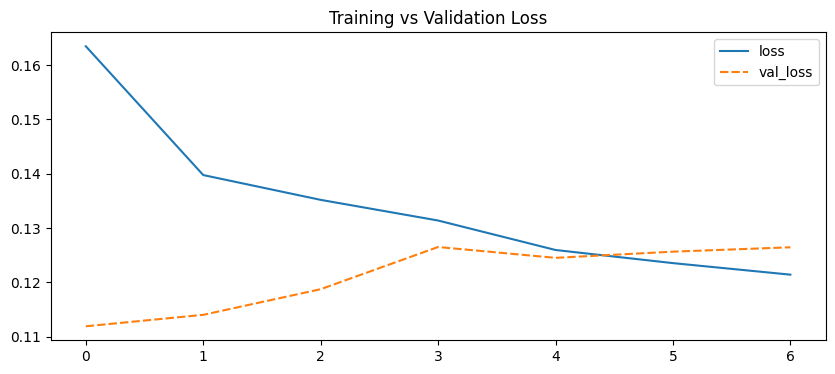

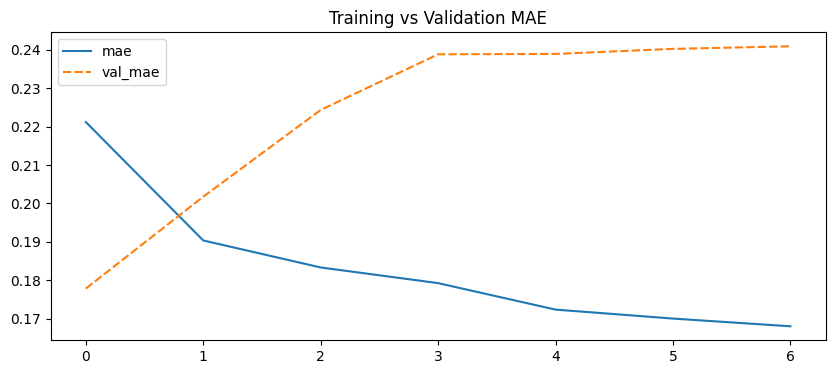

1140/1140 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step
   horizon_step        mae        rmse        r2
0             1  53.083599  106.045425  0.880539
1             2  64.926270  123.134764  0.838935
2             3  67.915174  125.849984  0.831753
3             4  70.088765  128.891683  0.823523
4             5  70.271214  129.662881  0.821403
5             6  71.625965  129.853667  0.820877
   sample_idx  horizon_step         target_time  ghi_actual   ghi_pred
0           0             1 2025-08-13 09:40:00        20.8  33.749432
1           0             2 2025-08-13 09:50:00        18.4  37.676388
2           0             3 2025-08-13 09:50:00        18.4  38.107937
3           0             4 2025-08-13 10:00:00        20.9  37.310497
4           0             5 2025-08-13 10:00:00        20.9  33.631268


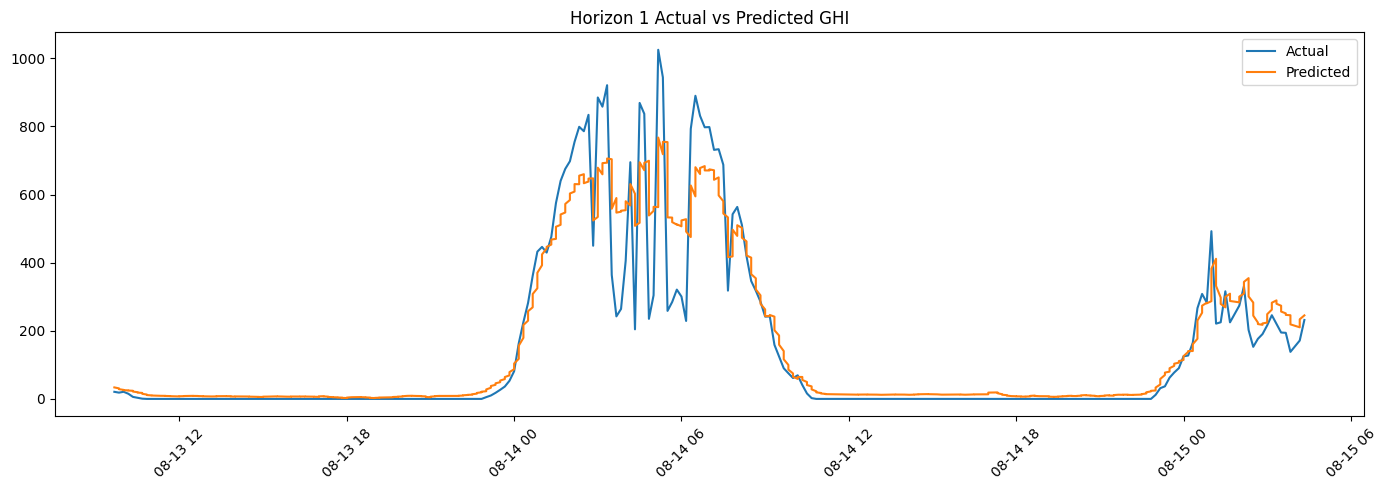

['x_scaler.joblib', 'test_predictions_long.csv', 'run_metadata.json', 'test_metrics_by_horizon.csv', 'asrs_sta6010_lstm_model.keras', 'y_scaler.joblib']


In [ ]:
import os
import json
import math
import random
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files
from tensorflow import keras
from tensorflow.keras import layers

SEED_VAL = 42
random.seed(SEED_VAL)
np.random.seed(SEED_VAL)
tf.random.set_seed(SEED_VAL)

DATA_PATH_CANDIDATES = [
    'asrs_sta6010_overlap_aware_preprocessing_v2_2023_2025.csv',
    'asrs_sta6010_basic_enriched_with_aws_v1.csv',
    'asrs_sta6010_basic_preprocessing_v1.csv',
    'asrs_sta6010_fe_v2_lstm_train_ready_full.csv'
]

# Find an existing data file
found_data_path = None
for path_name in DATA_PATH_CANDIDATES:
    if os.path.exists(path_name):
        found_data_path = path_name
        break

DATA_PATH = found_data_path

# If no existing data file is found, prompt for upload
if DATA_PATH is None:
    print("No existing data file found from candidates. Please upload the data file.")
    uploaded = files.upload()
    if uploaded:
        # Assuming the user uploads one file and it's the intended data file
        DATA_PATH = list(uploaded.keys())[0]
        print(f"File '{DATA_PATH}' uploaded successfully.")
    else:
        raise FileNotFoundError("No file was uploaded. Cannot proceed without a data file.")
else:
    print(f"Using existing data file: {DATA_PATH}")

LOOKBACK_STEPS = 18
HORIZON_STEPS = 6
TARGET_COL = 'ghi_basic'
TIME_COL = 'local_dt'
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
MODEL_DIR = 'asrs_lstm_outputs'
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, on_bad_lines='skip')
print(df.head())
print(df.shape)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Choose columns
id_cols = ['ts_utc', 'timestamp', 'local_dt', 'local_date', 'id_stasiun', 'nama_stasiun']
non_feature_cols = id_cols + ['dhi_basic', 'dni_basic']
feature_cols = [col_name for col_name in df.columns if col_name not in non_feature_cols]
feature_cols = [col_name for col_name in feature_cols if col_name != TARGET_COL] + [TARGET_COL]
print(feature_cols[:10])
print(len(feature_cols))

# Time-based split
n_rows = len(df)
train_end = int(n_rows * TRAIN_RATIO)
val_end = int(n_rows * (TRAIN_RATIO + VAL_RATIO))
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

# Scale using train only
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_raw = train_df[feature_cols].copy()
x_val_raw = val_df[feature_cols].copy()
x_test_raw = test_df[feature_cols].copy()

y_train_raw = train_df[[TARGET_COL]].copy()
y_val_raw = val_df[[TARGET_COL]].copy()
y_test_raw = test_df[[TARGET_COL]].copy()

# Ensure all feature columns are numeric before imputation
for col in feature_cols:
    if col in x_train_raw.columns:
        x_train_raw[col] = pd.to_numeric(x_train_raw[col], errors='coerce')
    if col in x_val_raw.columns:
        x_val_raw[col] = pd.to_numeric(x_val_raw[col], errors='coerce')
    if col in x_test_raw.columns:
        x_test_raw[col] = pd.to_numeric(x_test_raw[col], errors='coerce')

# Impute NaN values *after* splitting, using the mean from the training set to prevent data leakage
for col in feature_cols:
    if col in x_train_raw.columns:
        mean_val = x_train_raw[col].mean()
        x_train_raw[col].fillna(mean_val, inplace=True)
        x_val_raw[col].fillna(mean_val, inplace=True)
        x_test_raw[col].fillna(mean_val, inplace=True)

# Handle potential NaNs in target columns as well, using mean from training target
y_train_raw.fillna(y_train_raw.mean(), inplace=True)
y_val_raw.fillna(y_train_raw.mean(), inplace=True) # Use train mean for val/test
y_test_raw.fillna(y_train_raw.mean(), inplace=True) # Use train mean for val/test

x_train = x_scaler.fit_transform(x_train_raw)
x_val = x_scaler.transform(x_val_raw)
x_test = x_scaler.transform(x_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_val = y_scaler.transform(y_val_raw)
y_test = y_scaler.transform(y_test_raw)

joblib.dump(x_scaler, os.path.join(MODEL_DIR, 'x_scaler.joblib'))
joblib.dump(y_scaler, os.path.join(MODEL_DIR, 'y_scaler.joblib'))

# Sequence builder
feature_count = x_train.shape[1]
target_index = feature_cols.index(TARGET_COL)

def make_sequences(x_vals, y_vals, time_vals, lookback_steps, horizon_steps, target_pos):
    x_seq_list = []
    y_seq_list = []
    y_time_list = []
    max_start = len(x_vals) - lookback_steps - horizon_steps + 1
    for start_idx in tqdm(range(max_start)):
        end_hist = start_idx + lookback_steps
        end_target = end_hist + horizon_steps
        x_seq_list.append(x_vals[start_idx:end_hist, :])
        y_seq_list.append(y_vals[end_hist:end_target, 0])
        y_time_list.append(time_vals[end_hist:end_target])
    return np.array(x_seq_list), np.array(y_seq_list), np.array(y_time_list, dtype=object)

x_train_seq, y_train_seq, train_time_seq = make_sequences(x_train, y_train, train_df[TIME_COL].values, LOOKBACK_STEPS, HORIZON_STEPS, target_index)
x_val_seq, y_val_seq, val_time_seq = make_sequences(x_val, y_val, val_df[TIME_COL].values, LOOKBACK_STEPS, HORIZON_STEPS, target_index)
x_test_seq, y_test_seq, test_time_seq = make_sequences(x_test, y_test, test_df[TIME_COL].values, LOOKBACK_STEPS, HORIZON_STEPS, target_index)

print(x_train_seq.shape)
print(y_train_seq.shape)
print(x_val_seq.shape)
print(y_val_seq.shape)
print(x_test_seq.shape)
print(y_test_seq.shape)

# Build model
keras.backend.clear_session()
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK_STEPS, feature_count)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(HORIZON_STEPS)
])

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
print(model.summary())

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
    x_train_seq,
    y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)

model.save(os.path.join(MODEL_DIR, 'asrs_sta6010_lstm_model.keras'))

# Plot training curves
history_df = pd.DataFrame(history.history)
print(history_df.head())
plt.figure(figsize=(10, 4))
sns.lineplot(data=history_df[['loss', 'val_loss']])
plt.title('Training vs Validation Loss')
plt.show()

plt.figure(figsize=(10, 4))
sns.lineplot(data=history_df[['mae', 'val_mae']])
plt.title('Training vs Validation MAE')
plt.show()

# Evaluate on test
pred_scaled = model.predict(x_test_seq, verbose=1)
pred_flat = pred_scaled.reshape(-1, 1)
actual_flat = y_test_seq.reshape(-1, 1)

pred_inv = y_scaler.inverse_transform(pred_flat).reshape(-1, HORIZON_STEPS)
actual_inv = y_scaler.inverse_transform(actual_flat).reshape(-1, HORIZON_STEPS)

metrics_rows = []
for horizon_idx in range(HORIZON_STEPS):
    y_true_h = actual_inv[:, horizon_idx]
    y_pred_h = pred_inv[:, horizon_idx]
    mae_val = mean_absolute_error(y_true_h, y_pred_h)
    rmse_val = math.sqrt(mean_squared_error(y_true_h, y_pred_h))
    r2_val = r2_score(y_true_h, y_pred_h)
    metrics_rows.append({'horizon_step': horizon_idx + 1, 'mae': mae_val, 'rmse': rmse_val, 'r2': r2_val})
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df)
metrics_df.to_csv(os.path.join(MODEL_DIR, 'test_metrics_by_horizon.csv'), index=False)

# Save prediction frame
pred_rows = []
for sample_idx in range(len(pred_inv)):
    for horizon_idx in range(HORIZON_STEPS):
        pred_rows.append({
            'sample_idx': sample_idx,
            'horizon_step': horizon_idx + 1,
            'target_time': test_time_seq[sample_idx][horizon_idx], # Directly use datetime objects/NaT
            'ghi_actual': actual_inv[sample_idx, horizon_idx],
            'ghi_pred': pred_inv[sample_idx, horizon_idx]
        })
pred_df = pd.DataFrame(pred_rows)
# Ensure target_time is datetime type after creation
pred_df['target_time'] = pd.to_datetime(pred_df['target_time'], errors='coerce')

print(pred_df.head())
pred_df.to_csv(os.path.join(MODEL_DIR, 'test_predictions_long.csv'), index=False)

# Quick visualization
plot_df = pred_df[pred_df['horizon_step'] == 1].copy().head(500)
# Filter out NaT values from target_time for plotting
plot_df = plot_df.dropna(subset=['target_time'])
plt.figure(figsize=(14, 5))
plt.plot(plot_df['target_time'], plot_df['ghi_actual'], label='Actual') # No need for pd.to_datetime again
plt.plot(plot_df['target_time'], plot_df['ghi_pred'], label='Predicted')
plt.legend()
plt.title('Horizon 1 Actual vs Predicted GHI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save metadata
meta_obj = {
    'data_path': DATA_PATH,
    'rows': int(len(df)),
    'feature_count': int(feature_count),
    'lookback_steps': int(LOOKBACK_STEPS),
    'horizon_steps': int(HORIZON_STEPS),
    'target_col': TARGET_COL,
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df))
}
with open(os.path.join(MODEL_DIR, 'run_metadata.json'), 'w') as meta_file:
    json.dump(meta_obj, meta_file, indent=2)

print(os.listdir(MODEL_DIR))

In [ ]:
display(metrics_df)

,horizon_step,mae,rmse,r2
0,1,53.083599,106.045425,0.880539
1,2,64.926270,123.134764,0.838935
2,3,67.915174,125.849984,0.831753
3,4,70.088765,128.891683,0.823523
4,5,70.271214,129.662881,0.821403
5,6,71.625965,129.853667,0.820877


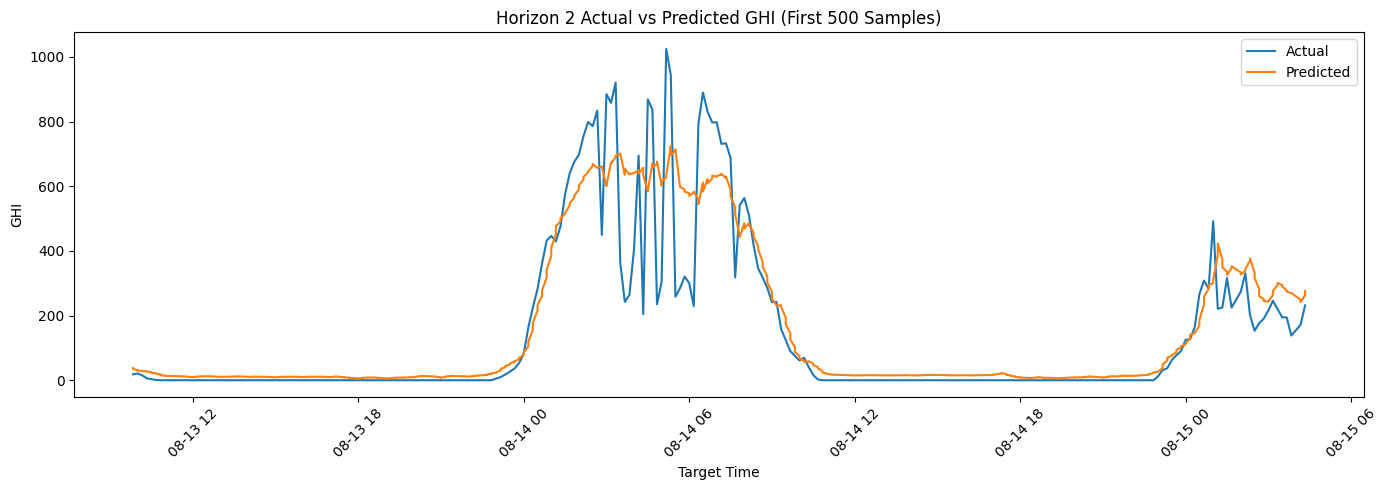

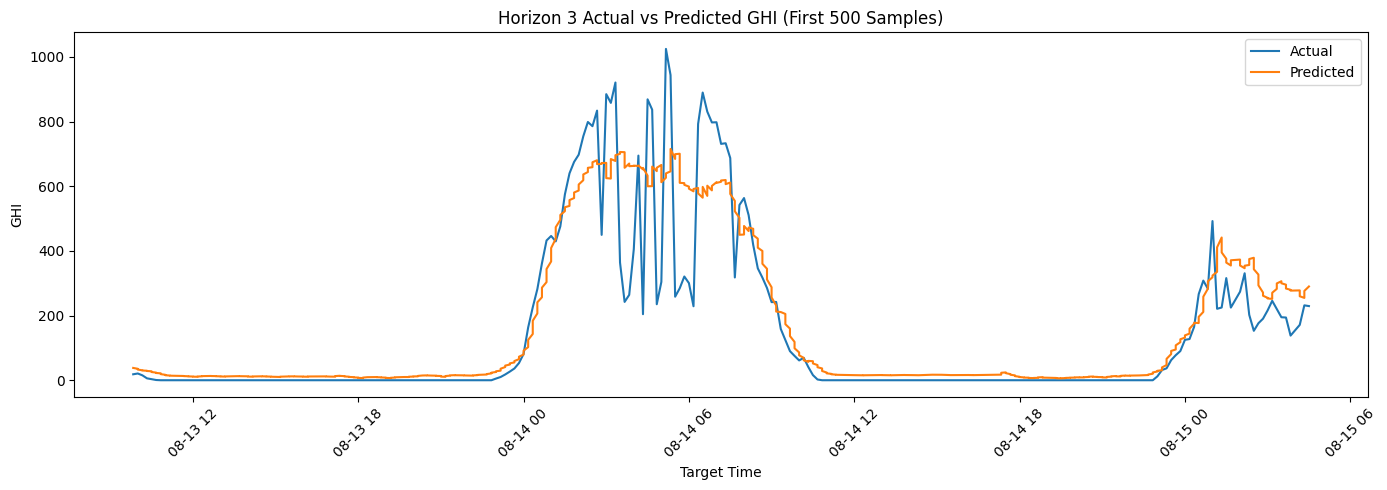

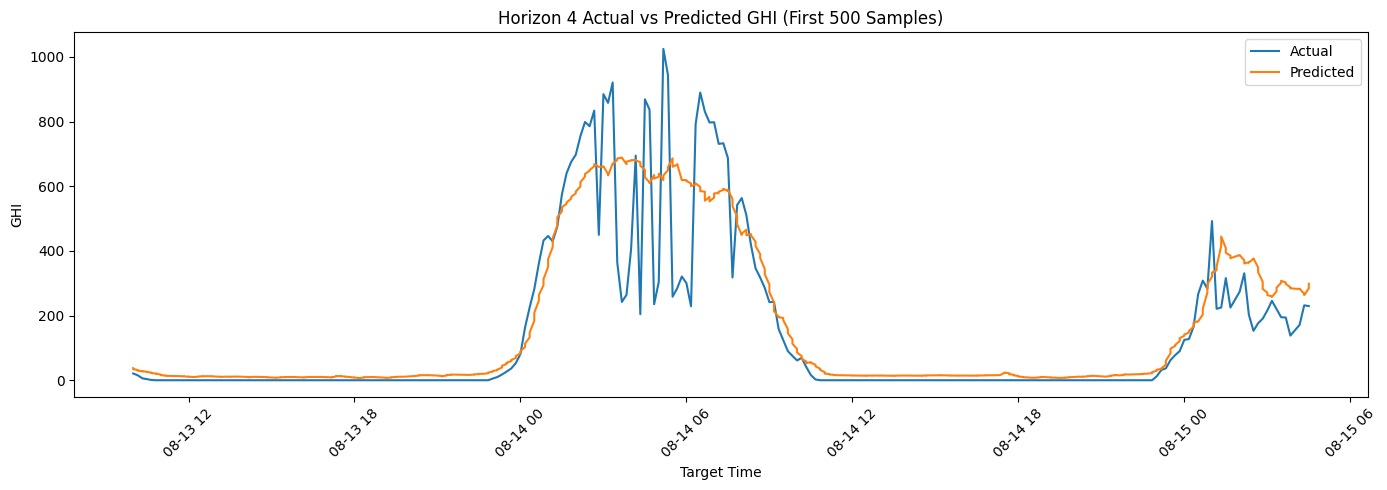

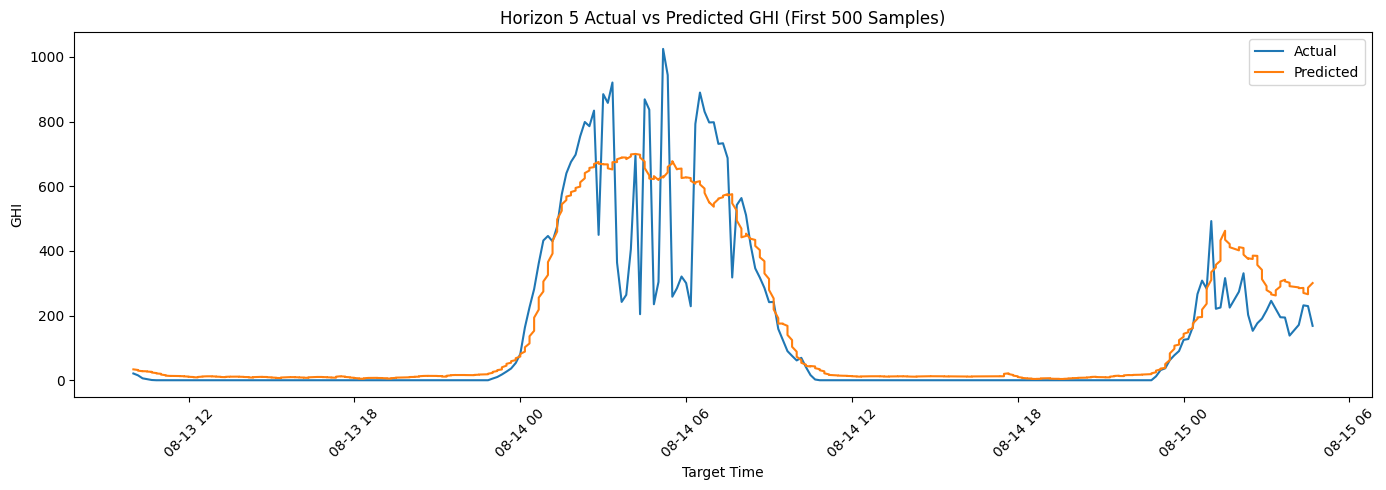

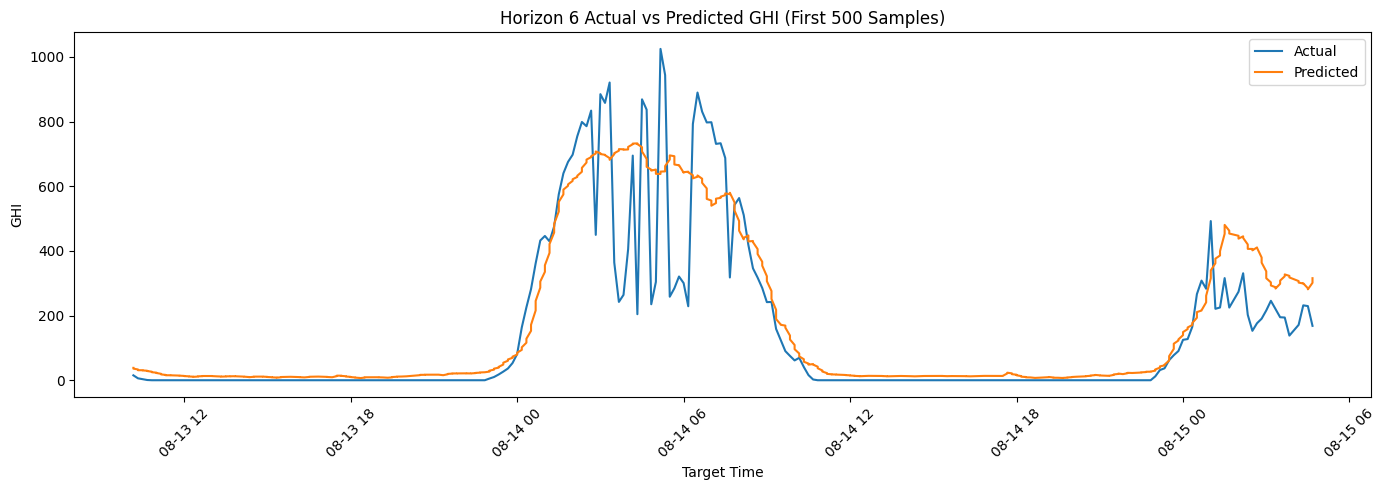

In [ ]:
def plot_horizon_predictions(horizon_step, pred_df, num_samples=500):
    """
    Plots actual vs predicted GHI for a given horizon step.

    Args:
        horizon_step (int): The horizon step to plot.
        pred_df (pd.DataFrame): The DataFrame containing predictions.
        num_samples (int): The number of samples to plot.
    """
    plot_df = pred_df[pred_df['horizon_step'] == horizon_step].copy().head(num_samples)
    plot_df = plot_df.dropna(subset=['target_time'])

    plt.figure(figsize=(14, 5))
    plt.plot(plot_df['target_time'], plot_df['ghi_actual'], label='Actual')
    plt.plot(plot_df['target_time'], plot_df['ghi_pred'], label='Predicted')
    plt.legend()
    plt.title(f'Horizon {horizon_step} Actual vs Predicted GHI (First {num_samples} Samples)')
    plt.xlabel('Target Time')
    plt.ylabel('GHI')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Visualize predictions for other horizons (2 to HORIZON_STEPS)
for i in range(2, HORIZON_STEPS + 1):
    plot_horizon_predictions(i, pred_df)


In [ ]:
# This cell builds a multi-horizon persistence baseline using the last observed GHI in each input window
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL = 'ghi_basic'
TIME_COL = 'local_dt'
LOOKBACK_STEPS = 18
HORIZON_STEPS = 6

# Make sure test_df is sorted
test_df = test_df.sort_values(TIME_COL).reset_index(drop=True)

y_true_persist_list = []
y_pred_persist_list = []
time_persist_list = []

max_start = len(test_df) - LOOKBACK_STEPS - HORIZON_STEPS + 1

for start_idx in tqdm(range(max_start)):
    end_hist = start_idx + LOOKBACK_STEPS
    end_target = end_hist + HORIZON_STEPS

    last_observed_val = test_df.iloc[end_hist - 1][TARGET_COL]
    future_true_vals = test_df.iloc[end_hist:end_target][TARGET_COL].values
    future_time_vals = test_df.iloc[end_hist:end_target][TIME_COL].values
    future_pred_vals = np.repeat(last_observed_val, HORIZON_STEPS)

    y_true_persist_list.append(future_true_vals)
    y_pred_persist_list.append(future_pred_vals)
    time_persist_list.append(future_time_vals)

persist_true = np.array(y_true_persist_list)
persist_pred = np.array(y_pred_persist_list)
persist_time = np.array(time_persist_list, dtype=object)

print(persist_true.shape)
print(persist_pred.shape)
print(pd.DataFrame({
    'y_true_h1': persist_true[:5, 0],
    'y_pred_h1': persist_pred[:5, 0]
}))

100%|██████████| 36459/36459 [00:22<00:00, 1602.74it/s]


(36459, 6)
(36459, 6)
   y_true_h1  y_pred_h1
0       20.8       20.8
1       18.4       20.8
2       18.4       18.4
3       20.9       18.4
4       20.9       20.9


In [ ]:
# This cell computes persistence baseline metrics for each forecast horizon
persist_metrics_rows = []

for horizon_idx in tqdm(range(HORIZON_STEPS)):
    y_true_h = persist_true[:, horizon_idx]
    y_pred_h = persist_pred[:, horizon_idx]

    mae_val = mean_absolute_error(y_true_h, y_pred_h)
    rmse_val = math.sqrt(mean_squared_error(y_true_h, y_pred_h))
    r2_val = r2_score(y_true_h, y_pred_h)

    persist_metrics_rows.append({
        'horizon_step': horizon_idx + 1,
        'mae_persistence': mae_val,
        'rmse_persistence': rmse_val,
        'r2_persistence': r2_val
    })

persist_metrics_df = pd.DataFrame(persist_metrics_rows)
print(persist_metrics_df)
persist_metrics_df.to_csv('persistence_baseline_metrics.csv', index=False)
print('persistence_baseline_metrics.csv')

100%|██████████| 6/6 [00:00<00:00, 61.39it/s]

   horizon_step  mae_persistence  rmse_persistence  r2_persistence
0             1        29.859221        105.663228        0.881399
1             2        59.606604        149.135497        0.763733
2             3        66.937513        158.576192        0.732874
3             4        74.215956        167.325403        0.702585
4             5        79.431648        173.131915        0.681583
5             6        84.567482        178.531091        0.661413
persistence_baseline_metrics.csv


In [ ]:
# This cell recreates the final LSTM metrics table from the confirmed Colab results
lstm_metrics_df = pd.DataFrame([
    {'horizon_step': 1, 'mae_lstm': 53.083599, 'rmse_lstm': 106.045425, 'r2_lstm': 0.880539},
    {'horizon_step': 2, 'mae_lstm': 64.926270, 'rmse_lstm': 123.134764, 'r2_lstm': 0.838935},
    {'horizon_step': 3, 'mae_lstm': 67.915174, 'rmse_lstm': 125.849984, 'r2_lstm': 0.831753},
    {'horizon_step': 4, 'mae_lstm': 70.088765, 'rmse_lstm': 128.891683, 'r2_lstm': 0.823523},
    {'horizon_step': 5, 'mae_lstm': 70.271214, 'rmse_lstm': 129.662881, 'r2_lstm': 0.821403},
    {'horizon_step': 6, 'mae_lstm': 71.625965, 'rmse_lstm': 129.853667, 'r2_lstm': 0.820877}
])

print(lstm_metrics_df)

   horizon_step   mae_lstm   rmse_lstm   r2_lstm
0             1  53.083599  106.045425  0.880539
1             2  64.926270  123.134764  0.838935
2             3  67.915174  125.849984  0.831753
3             4  70.088765  128.891683  0.823523
4             5  70.271214  129.662881  0.821403
5             6  71.625965  129.853667  0.820877


In [ ]:
# This cell compares LSTM against the persistence baseline and computes absolute and percentage improvements
comparison_df = lstm_metrics_df.merge(persist_metrics_df, on='horizon_step', how='inner')

comparison_df['mae_improvement_abs'] = comparison_df['mae_persistence'] - comparison_df['mae_lstm']
comparison_df['rmse_improvement_abs'] = comparison_df['rmse_persistence'] - comparison_df['rmse_lstm']
comparison_df['r2_improvement_abs'] = comparison_df['r2_lstm'] - comparison_df['r2_persistence']

comparison_df['mae_improvement_pct'] = 100.0 * comparison_df['mae_improvement_abs'] / comparison_df['mae_persistence']
comparison_df['rmse_improvement_pct'] = 100.0 * comparison_df['rmse_improvement_abs'] / comparison_df['rmse_persistence']

print(comparison_df.round(4))
comparison_df.to_csv('lstm_vs_persistence_comparison.csv', index=False)
print('lstm_vs_persistence_comparison.csv')

   horizon_step  mae_lstm  rmse_lstm  r2_lstm  mae_persistence  \
0             1   53.0836   106.0454   0.8805          29.8592   
1             2   64.9263   123.1348   0.8389          59.6066   
2             3   67.9152   125.8500   0.8318          66.9375   
3             4   70.0888   128.8917   0.8235          74.2160   
4             5   70.2712   129.6629   0.8214          79.4316   
5             6   71.6260   129.8537   0.8209          84.5675   

   rmse_persistence  r2_persistence  mae_improvement_abs  \
0          105.6632          0.8814             -23.2244   
1          149.1355          0.7637              -5.3197   
2          158.5762          0.7329              -0.9777   
3          167.3254          0.7026               4.1272   
4          173.1319          0.6816               9.1604   
5          178.5311          0.6614              12.9415   

   rmse_improvement_abs  r2_improvement_abs  mae_improvement_pct  \
0               -0.3822             -0.0009     

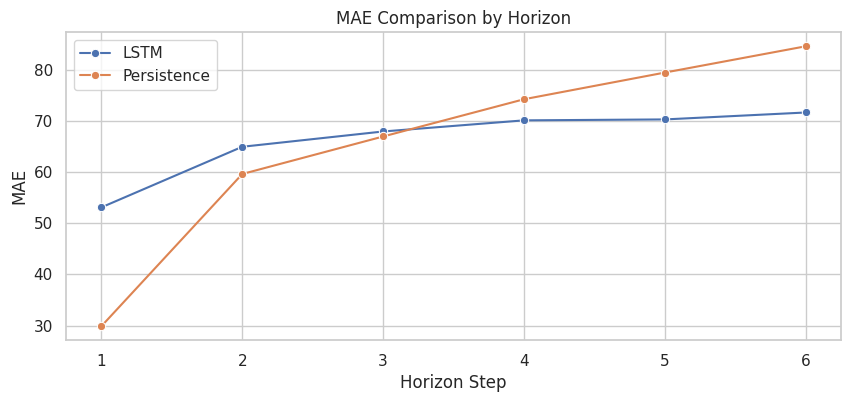

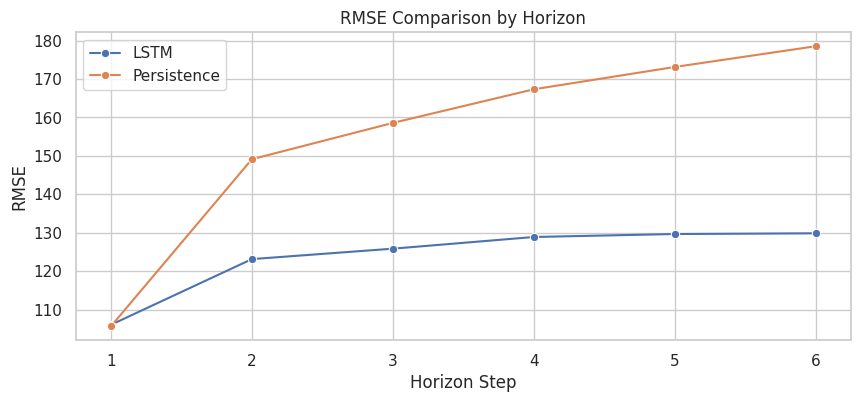

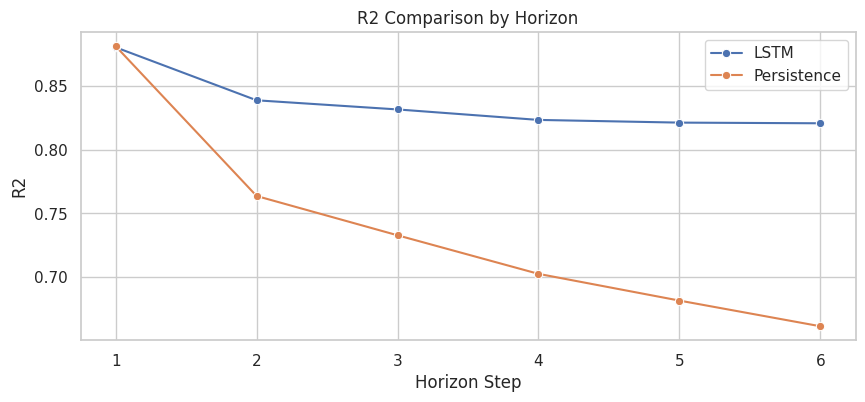

In [ ]:
# This cell visualizes LSTM versus persistence across forecast horizons
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 4))
sns.lineplot(data=comparison_df, x='horizon_step', y='mae_lstm', marker='o', label='LSTM')
sns.lineplot(data=comparison_df, x='horizon_step', y='mae_persistence', marker='o', label='Persistence')
plt.title('MAE Comparison by Horizon')
plt.xlabel('Horizon Step')
plt.ylabel('MAE')
plt.show()

plt.figure(figsize=(10, 4))
sns.lineplot(data=comparison_df, x='horizon_step', y='rmse_lstm', marker='o', label='LSTM')
sns.lineplot(data=comparison_df, x='horizon_step', y='rmse_persistence', marker='o', label='Persistence')
plt.title('RMSE Comparison by Horizon')
plt.xlabel('Horizon Step')
plt.ylabel('RMSE')
plt.show()

plt.figure(figsize=(10, 4))
sns.lineplot(data=comparison_df, x='horizon_step', y='r2_lstm', marker='o', label='LSTM')
sns.lineplot(data=comparison_df, x='horizon_step', y='r2_persistence', marker='o', label='Persistence')
plt.title('R2 Comparison by Horizon')
plt.xlabel('Horizon Step')
plt.ylabel('R2')
plt.show()

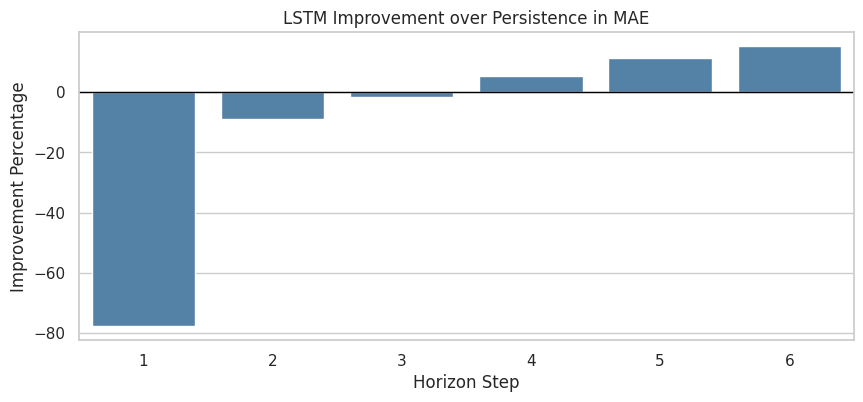

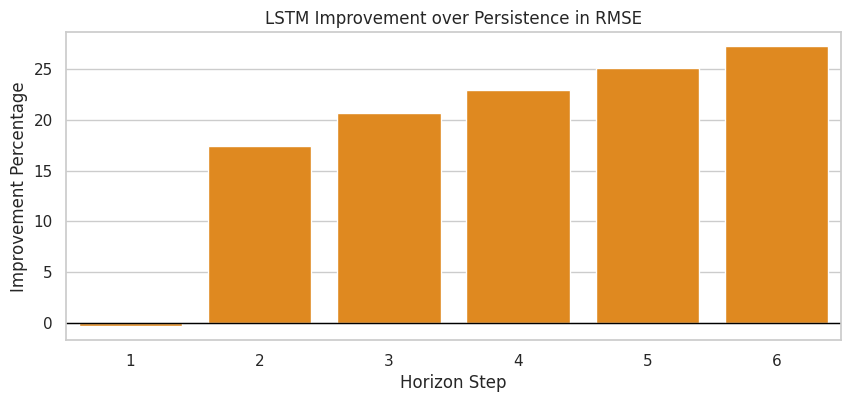

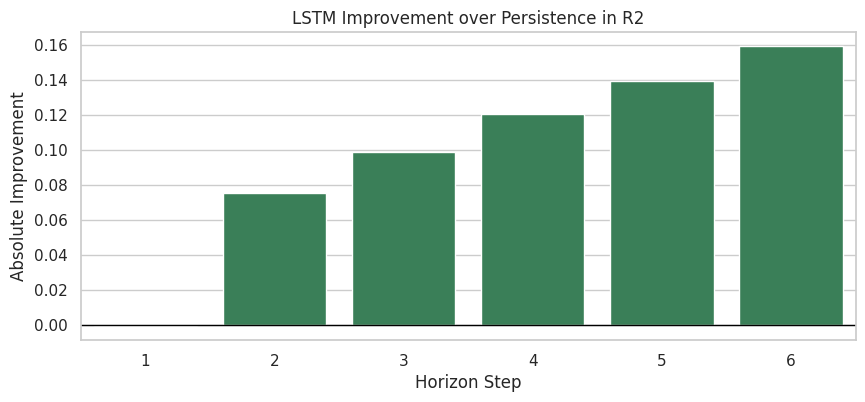

In [ ]:
# This cell plots how much LSTM improves over persistence
plt.figure(figsize=(10, 4))
sns.barplot(data=comparison_df, x='horizon_step', y='mae_improvement_pct', color='steelblue')
plt.axhline(0, color='black', linewidth=1)
plt.title('LSTM Improvement over Persistence in MAE')
plt.xlabel('Horizon Step')
plt.ylabel('Improvement Percentage')
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=comparison_df, x='horizon_step', y='rmse_improvement_pct', color='darkorange')
plt.axhline(0, color='black', linewidth=1)
plt.title('LSTM Improvement over Persistence in RMSE')
plt.xlabel('Horizon Step')
plt.ylabel('Improvement Percentage')
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=comparison_df, x='horizon_step', y='r2_improvement_abs', color='seagreen')
plt.axhline(0, color='black', linewidth=1)
plt.title('LSTM Improvement over Persistence in R2')
plt.xlabel('Horizon Step')
plt.ylabel('Absolute Improvement')
plt.show()

In [ ]:
# This cell prints a concise textual summary for report writing
avg_mae_gain = comparison_df['mae_improvement_pct'].mean()
avg_rmse_gain = comparison_df['rmse_improvement_pct'].mean()
avg_r2_gain = comparison_df['r2_improvement_abs'].mean()

print('Average MAE improvement percentage')
print(round(avg_mae_gain, 2))

print('Average RMSE improvement percentage')
print(round(avg_rmse_gain, 2))

print('Average absolute R2 improvement')
print(round(avg_r2_gain, 4))

best_mae_row = comparison_df.loc[comparison_df['mae_improvement_pct'].idxmax()]
best_rmse_row = comparison_df.loc[comparison_df['rmse_improvement_pct'].idxmax()]

print('Best MAE improvement horizon')
print(best_mae_row[['horizon_step', 'mae_improvement_pct']])

print('Best RMSE improvement horizon')
print(best_rmse_row[['horizon_step', 'rmse_improvement_pct']])

Average MAE improvement percentage
-9.29
Average RMSE improvement percentage
18.84
Average absolute R2 improvement
0.0989
Best MAE improvement horizon
horizon_step            6.000000
mae_improvement_pct    15.303184
Name: 5, dtype: float64
Best RMSE improvement horizon
horizon_step             6.000000
rmse_improvement_pct    27.265516
Name: 5, dtype: float64
